## **Projet de classification d'image de cellules afin de détecter le parasite de la Malaria** ##

In [21]:
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import os
%reload_ext autoreload
%autoreload 2
import modele 

### 1. Chargement du jeu de donnée ###

In [2]:
data, target = modele.load_images(
    "cell_images/Uninfected",
    "cell_images/Parasitized"
)

data = np.asarray(data)
target = np.asarray(target)

print(data)
print(data.shape)
print(data.min())
print(data.max())
print(data.mean())

[[-1.31933224 -1.31933224 -1.13728635 ... -1.31933224 -1.31933224
  -1.31933224]
 [-1.2578559  -1.2578559  -1.2578559  ... -1.2578559  -1.2578559
  -1.2578559 ]
 [-1.37146945 -1.37146945 -1.37146945 ... -1.37146945 -1.37146945
  -1.37146945]
 ...
 [-1.22838388 -1.22838388 -1.22838388 ... -1.22838388 -1.22838388
  -1.22838388]
 [-1.26662697 -1.26662697 -1.26662697 ... -1.26662697 -1.26662697
  -1.26662697]
 [-1.26995125 -1.26995125 -1.26995125 ... -1.26995125 -1.26995125
  -1.26995125]]
(400, 256)
-1.6323070546251621
2.117256454558267
-1.0755285551056204e-18


## 2. Test du modèle simple ##

In [ ]:
indices = np.arange(len(data))
np.random.seed(42) #pour la reproductibilité
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b = modele.mlp_fit(
        X_train,
        y_train,
        n_epochs=100,
        hidden_layer_sizes=[16, 8],
        learning_rate=0.1,
        random_state=42
    )



    # test
    correct = 0

    for i in range(len(X_test)):
        pred = modele.predict(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

modele.save_model("modele_simple.npz", w, b)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.7625

===== Fold 2 =====
Accuracy : 0.625

===== Fold 3 =====
Accuracy : 0.7125

===== Fold 4 =====
Accuracy : 0.7

===== Fold 5 =====
Accuracy : 0.6875

Accuracy moyenne : 0.6975
(320, 256)
(80, 256)


ReLu

In [4]:
indices = np.arange(len(data))
np.random.seed(42)
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b, losses = modele.mlp_fit_relu(
        X_train,
        y_train,
        n_epochs=100,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = modele.predict_relu(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.7625

===== Fold 2 =====
Accuracy : 0.6

===== Fold 3 =====
Accuracy : 0.7

===== Fold 4 =====
Accuracy : 0.65

===== Fold 5 =====
Accuracy : 0.6125

Accuracy moyenne : 0.665
(320, 256)
(80, 256)


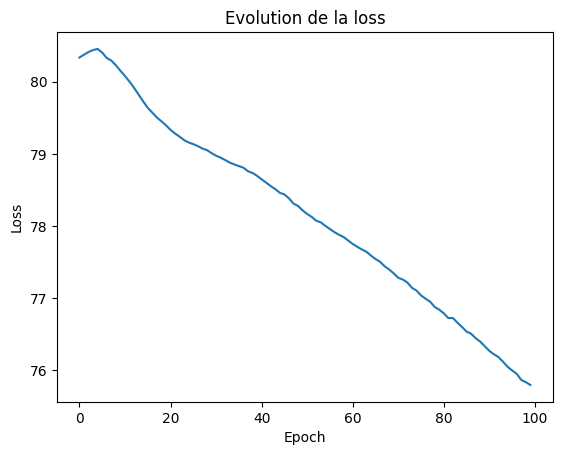

In [5]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss")

plt.show()

Binary Cross Entropy

In [6]:
indices = np.arange(len(data))
np.random.seed(42)
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b, losses = modele.mlp_fit_bce(
        X_train,
        y_train,
        n_epochs=500,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = modele.predict_relu(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.7375

===== Fold 2 =====
Accuracy : 0.625

===== Fold 3 =====
Accuracy : 0.6875

===== Fold 4 =====
Accuracy : 0.675

===== Fold 5 =====
Accuracy : 0.6625

Accuracy moyenne : 0.6775
(320, 256)
(80, 256)


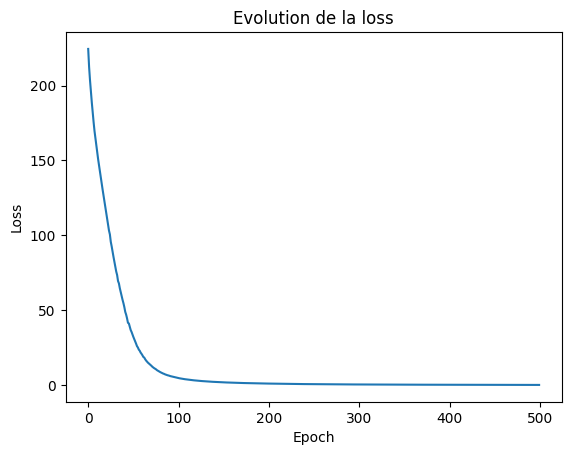

In [7]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolution de la loss")

plt.show()

In [8]:
proba = modele.predict_proba_dropout(X_test[0], w, b)
print(proba)
print(type(proba))


0.5752536077166613
<class 'numpy.float64'>


Dropout

In [9]:
indices = np.arange(len(data))
np.random.seed(42)
np.random.shuffle(indices)

n_splits = 5

folds = np.array_split(indices, n_splits)

accuracies = []

for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b, losses = modele.mlp_fit_dropout(
        X_train,
        y_train,
        n_epochs=500,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = modele.predict_dropout(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.675

===== Fold 2 =====
Accuracy : 0.6

===== Fold 3 =====
Accuracy : 0.6375

===== Fold 4 =====
Accuracy : 0.675

===== Fold 5 =====
Accuracy : 0.5625

Accuracy moyenne : 0.63
(320, 256)
(80, 256)


In [18]:
modele.load_model("modele_simple.npz")

([array([], shape=(0, 0), dtype=float64),
  array([[ 0.05565899, -0.04378331,  0.16804304, ..., -0.06695974,
           0.00565028,  0.08947701],
         [ 0.12032654,  0.03807306,  0.0415217 , ...,  0.08385644,
          -0.0919372 ,  0.05435985],
         [ 0.02987191,  0.03418648,  0.12273833, ..., -0.1387545 ,
           0.02464853, -0.03090279],
         ...,
         [-0.05670983, -0.03516074,  0.05811217, ...,  0.23167154,
           0.03445026, -0.01112434],
         [ 0.05682573,  0.1980709 , -0.07283076, ...,  0.0015718 ,
           0.00439328,  0.0150059 ],
         [-0.12241104, -0.01799078,  0.0137771 , ..., -0.1141743 ,
           0.04689471, -0.15743821]], shape=(16, 256)),
  array([[-0.39873452,  0.72865547,  0.73646012, -0.89865751, -0.32180334,
           0.40946782,  0.02324559,  0.06685967, -0.86988559,  0.71485385,
          -1.18068256,  0.9923092 ,  0.37368477, -0.56717584, -0.01227186,
          -0.18777034],
         [-0.49577644,  0.42543809,  0.16069857, -0.

Mini Batch Gradient

In [23]:
for k in range(n_splits):

    print(f"\n===== Fold {k+1} =====")

    # fold de test
    test_idx = folds[k]

    # folds d'entraînement
    train_idx = np.concatenate(
        [folds[i] for i in range(n_splits) if i != k]
    )

    # séparation des données
    X_train = data[train_idx]
    y_train = target[train_idx]

    X_test = data[test_idx]
    y_test = target[test_idx]

    # entraînement
    w, b = modele.mlp_fit_minibatch(
        X_train,
        y_train,
        n_epochs=500,
        hidden_layer_sizes=[32, 16],
        learning_rate=0.001,
        random_state=42
    )

    # test
    correct = 0

    for i in range(len(X_test)):
        pred = modele.predict(X_test[i], w, b)

        if pred == y_test[i]:
            correct += 1

    accuracy = correct / len(X_test)

    print("Accuracy :", accuracy)

    accuracies.append(accuracy)

print("\nAccuracy moyenne :", np.mean(accuracies))
print(X_train.shape)
print(X_test.shape)


===== Fold 1 =====
Accuracy : 0.4375

===== Fold 2 =====
Accuracy : 0.525

===== Fold 3 =====
Accuracy : 0.575

===== Fold 4 =====
Accuracy : 0.5

===== Fold 5 =====
Accuracy : 0.5125

Accuracy moyenne : 0.60375
(320, 256)
(80, 256)
